# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Abdi Fhilipus Tampubolon
- **Email:** cdcc306d6y0417@student.devacademy.id
- **ID Dicoding:** CDCC306D6Y0417

## Menentukan Pertanyaan Bisnis (SMART)
1. **Pertanyaan 1:** Bagaimana pengaruh musim (*season*) terhadap rata-rata jumlah penyewaan sepeda harian selama tahun 2012?
2. **Pertanyaan 2:** Apakah terdapat perbedaan pola penyewaan sepeda per jam antara hari kerja (*workingday*) dan hari libur sepanjang tahun 2011-2012?

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Gathering Data
day_df = pd.read_csv('day.csv')
hour_df = pd.read_csv('hour.csv')

print("Data Harian (head):")
display(day_df.head(3))

Data Harian (head):


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349


## Assessing Data
Dari hasil observasi awal, kita nemuin 2 masalah utama yang butuh penanganan:
1. **Inaccurate Data Type:** Kolom `dteday` tipe datanya masih `object` (string), padahal merepresentasikan tanggal, jadi harusnya `datetime`.
2. **Uninformative Values:** Kolom kategorikal seperti `season`, `weathersit`, dan `yr` direpresentasikan dengan angka numerik (1, 2, 3, 4). Ini bikin bingung pas *exploratory* dan visualisasi, jadi harus di-mapping ke label aslinya.

In [6]:
# Cleaning Data

# 1. Benerin tipe data dteday jadi datetime
day_df['dteday'] = pd.to_datetime(day_df['dteday'])
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])

# 2. Mapping nilai kategorik
season_map = {1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'}
yr_map = {0: 2011, 1: 2012}
workingday_map = {0: 'Hari Libur', 1: 'Hari Kerja'}

day_df['season'] = day_df['season'].map(season_map)
hour_df['season'] = hour_df['season'].map(season_map)

day_df['yr'] = day_df['yr'].map(yr_map)
hour_df['workingday_label'] = hour_df['workingday'].map(workingday_map)

print("Data selesai dicleaning!!")

Data selesai dicleaning!!


## Exploratory Data Analysis (EDA) & Advanced Analysis
Mencari insigt dari data untuk jawab pertanyaan bisnis tadi. Lakukan **Clustering (Binning)** buat ngebagi hari berdasarkan tingkat keramaian permintaan sepeda (*Low, Medium, High Demand*).

In [7]:
# EDA Q1: Rata-rata sewa per musim (Tahun 2012)
day_2012 = day_df[day_df['yr'] == 2012]
season_trend = day_2012.groupby('season')['cnt'].mean().sort_values(ascending=False).reset_index()

# EDA Q2: Pola per jam (hari kerja vs libur)
hourly_trend = hour_df.groupby(['hr', 'workingday_label'])['cnt'].mean().reset_index()

# Advanced Analysis: Clustering / Binning
# Ngelompokkin total penyewaan harian jadi 3 kategori demand pake qcut
day_df['demand_category'] = pd.qcut(day_df['cnt'], q=3, labels=['Low Demand', 'Medium Demand', 'High Demand'])

# Export data utama buat dipake di Streamlit Dashboard
day_df.to_csv("main_data.csv", index=False)

print("\nHasil Clustering Manual (Binning) Harian:\n", day_df['demand_category'].value_counts())


Hasil Clustering Manual (Binning) Harian:
 demand_category
Low Demand       244
Medium Demand    244
High Demand      243
Name: count, dtype: int64


/tmp/ipykernel_2259/267212808.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='season', y='cnt', data=season_trend, palette='viridis')


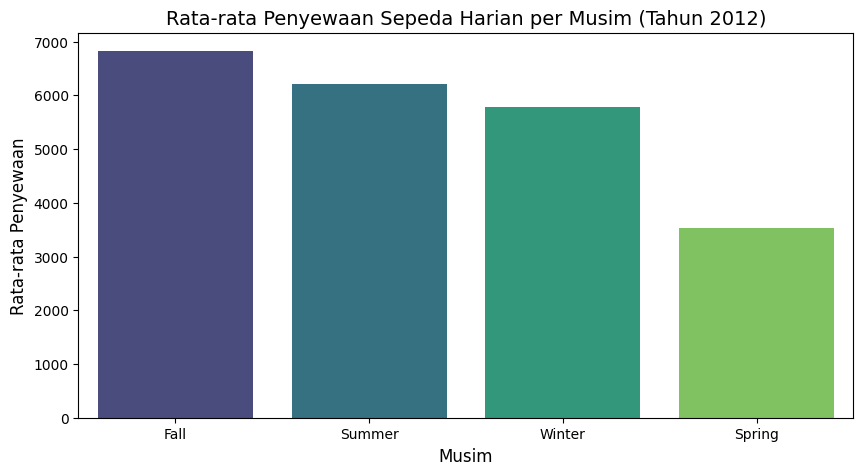

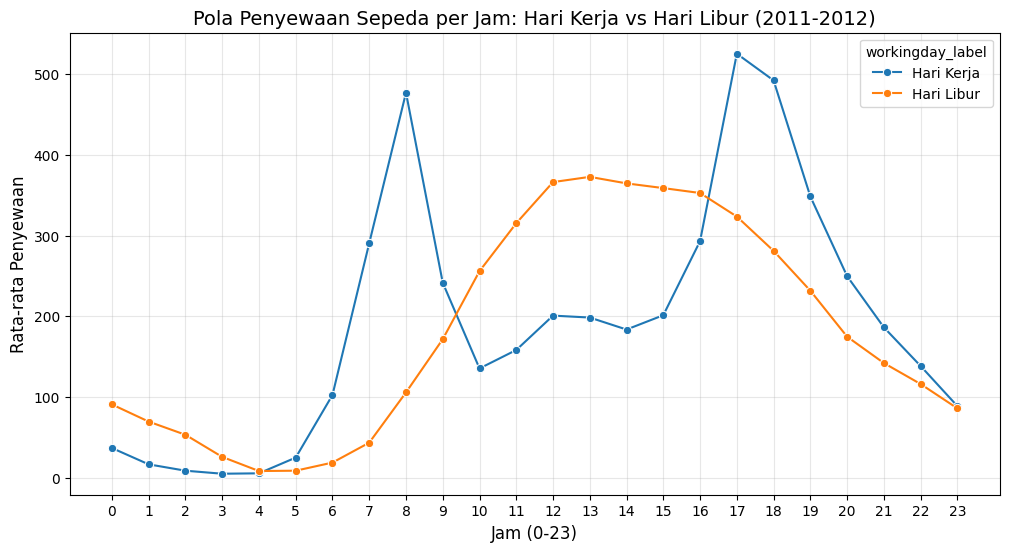

In [8]:
## Visualization & Explanatory Analysis

# Plot buat Q1
plt.figure(figsize=(10, 5))
sns.barplot(x='season', y='cnt', data=season_trend, palette='viridis')
plt.title('Rata-rata Penyewaan Sepeda Harian per Musim (Tahun 2012)', fontsize=14)
plt.xlabel('Musim', fontsize=12)
plt.ylabel('Rata-rata Penyewaan', fontsize=12)
plt.show()

# Plot buat Q2
plt.figure(figsize=(12, 6))
sns.lineplot(x='hr', y='cnt', hue='workingday_label', data=hourly_trend, marker='o')
plt.title('Pola Penyewaan Sepeda per Jam: Hari Kerja vs Hari Libur (2011-2012)', fontsize=14)
plt.xlabel('Jam (0-23)', fontsize=12)
plt.ylabel('Rata-rata Penyewaan', fontsize=12)
plt.xticks(np.arange(0, 24, 1))
plt.grid(True, alpha=0.3)
plt.show()

## Kesimpulan & Rekomendasi (Action Item)

- **Kesimpulan 1:** Musim dengan rata-rata penyewaan tertinggi di tahun 2012 adalah musim gugur (*Fall*), disusul oleh *Summer*, sementara *Spring* mencatat rata-rata terendah. Cuaca sejuk terbukti mendorong minat bersepeda lebih tinggi.
- **Kesimpulan 2:** Terdapat pola jam sibuk yang jauh berbeda. Di **Hari Kerja**, *peak hours* melonjak drastis pada jam masuk kerja (08:00) dan pulang kerja (17:00-18:00). Sebaliknya, di **Hari Libur**, penyewaan baru merangkak naik perlahan dan stabil tinggi dari siang hingga sore hari (12:00-16:00).
- **Rekomendasi Action Item:** Tim operasional harus menggeser dan mengoptimalkan penempatan unit sepeda (armada) ke stasiun-stasiun yang dekat dengan perkantoran dan transit publik pada pukul 07:30 dan 16:30 di hari kerja. Untuk hari libur dan di musim gugur (*Fall*), unit sepeda bisa direlokasi ke stasiun dekat taman atau area rekreasi mulai jam 11:00 siang untuk menangkap lonjakan *demand* pengguna kasual.